# Avaliação Científica de Re-ranking Neural em Dois Estágios (Two-Stage RAG)
## Projeto de Pesquisa Científica e Tecnológica (ICT) — Engenharia de Software / Ciência da Computação
**Estudo de Caso:** Recuperação de Informação em Manuais Técnicos de No-breaks Industriais (CM Comandos Lineares)  
**Hardware de Execução:** NVIDIA RTX PRO 1000 Blackwell Laptop GPU (8 GB GDDR6), Intel Core Ultra 7 265H CPU, 32 GB RAM  
**Ambiente de Inferência:** Ollama (LLaMA C++ / GGML), HuggingFace Sentence-Transformers, OpenAI API (RankGPT Baseline)

---

### Resumo do Experimento
Neste notebook avaliamos a arquitetura de **RAG em Dois Estágios (*Two-Stage Retrieval & Re-ranking*)** aplicada a 16 manuais de no-breaks industriais.
O primeiro estágio recupera uma lista expandida de $K_{\text{cand}} = 20$ candidatos via bi-encoder denso. O segundo estágio emprega modelos de re-ranking (Cross-Encoders e SLMs baseados em logprobs) para reordenar os nós antes do envio ao gerador.

São avaliados:
1. **Modelos de 1º Estágio (Top-2 do Benchmark de Embeddings):**
   - `qwen3_8b_q4km` (Ollama, Q4_K_M)
   - `multilingual_e5_large` (HuggingFace / PyTorch, FP16)
2. **Reordenadores Neurais de 2º Estágio:**
   - **Baseline Puro:** `none` (Top-K direto do 1º estágio sem reordenação)
   - **SLM Local 4B:** `dengcao/Qwen3-Reranker-4B:Q4_K_M` (Ollama, binary logprob softmax)
   - **SLM Local 8B:** `dengcao/Qwen3-Reranker-8B:Q5_K_M` (Ollama, binary logprob softmax)
   - **Cross-Encoder Dedicado:** `BAAI/bge-reranker-v2-m3` (HuggingFace PyTorch)
   - **Baseline Comercial de Nuvem:** `RankGPT` baseado em `gpt-4o-mini` (OpenAI API via prompt listwise)


In [1]:
import os
import json
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo científico dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "figure.autolayout": True,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

print("Ambiente configurado com sucesso.")


Ambiente configurado com sucesso.


## 1. Carregamento dos Dados Experimentais Consolidados
Os dados a seguir foram extraídos a partir de 128 consultas reais deduplicadas, confrontadas com o Ground Truth técnico via casamento multicamada determinístico (*Matching Engine* em 3 camadas: Contenção de Substring, RapidFuzz Token Set e ROUGE-L).


In [2]:
csv_path = "../results/consolidated_reranker_metrics.csv"
if not os.path.exists(csv_path):
    csv_path = "results/consolidated_reranker_metrics.csv"

df = pd.read_csv(csv_path)

# Mapeamento para nomes legíveis
MODEL_LABELS = {
    "none": "Baseline Puro (Sem Re-ranking)",
    "qwen3_4b_q4km": "Qwen3-Reranker-4B (Q4_K_M)",
    "qwen3_8b_q5km": "Qwen3-Reranker-8B (Q5_K_M)",
    "bge_reranker_v2_m3": "BGE-Reranker-v2-m3 (HF)",
    "rankgpt": "RankGPT (gpt-4o-mini)",
}

BASE_LABELS = {
    "qwen3_8b_q4km": "Qwen3-Embedding-8B (Q4_K_M)",
    "multilingual_e5_large": "Multilingual-E5-Large (FP16)",
}

df["reranker_name"] = df["reranker"].map(MODEL_LABELS)
df["base_name"] = df["base_model"].map(BASE_LABELS)

# Exibe tabela consolidada formatada
cols_display = [
    "base_name", "reranker_name", "hit_rate@5_mean", "mrr@5_mean",
    "recall@5_mean", "map@5_mean", "delta_mrr@5", "p_value_wilcoxon_mrr5", "mean_latency_ms"
]
df_display = df[cols_display].rename(columns={
    "base_name": "Modelo Base (1º Estágio)",
    "reranker_name": "Reranker (2º Estágio)",
    "hit_rate@5_mean": "HR@5",
    "mrr@5_mean": "MRR@5",
    "recall@5_mean": "Recall@5",
    "map@5_mean": "MAP@5",
    "delta_mrr@5": "Δ MRR@5",
    "p_value_wilcoxon_mrr5": "Wilcoxon (p)",
    "mean_latency_ms": "Latência (ms)",
})

df_display.style.format({
    "HR@5": "{:.2%}",
    "MRR@5": "{:.4f}",
    "Recall@5": "{:.2%}",
    "MAP@5": "{:.4f}",
    "Δ MRR@5": "{:+.4f}",
    "Wilcoxon (p)": "{:.4f}",
    "Latência (ms)": "{:.1f}",
}).background_gradient(subset=["MRR@5", "HR@5"], cmap="YlGn")


,Modelo Base (1º Estágio),Reranker (2º Estágio),HR@5,MRR@5,Recall@5,MAP@5,Δ MRR@5,Wilcoxon (p),Latência (ms)
0,Multilingual-E5-Large (FP16),Baseline Puro (Sem Re-ranking),54.69%,0.4031,51.10%,0.6523,+0.0000,1.0000,0.0
1,Multilingual-E5-Large (FP16),BGE-Reranker-v2-m3 (HF),57.03%,0.4982,55.35%,0.9831,+0.0951,0.0261,1164.3
2,Multilingual-E5-Large (FP16),Qwen3-Reranker-4B (Q4_K_M),62.50%,0.4764,59.58%,0.8791,+0.0733,0.0406,6211.0
3,Multilingual-E5-Large (FP16),Qwen3-Reranker-8B (Q5_K_M),65.62%,0.4975,57.84%,0.8984,+0.0944,0.0023,6894.9
4,Multilingual-E5-Large (FP16),RankGPT (gpt-4o-mini),61.72%,0.4573,57.74%,0.7845,+0.0542,0.0510,1723.0
5,Qwen3-Embedding-8B (Q4_K_M),Baseline Puro (Sem Re-ranking),57.03%,0.3887,53.11%,0.6836,+0.0000,1.0000,0.0
6,Qwen3-Embedding-8B (Q4_K_M),BGE-Reranker-v2-m3 (HF),53.91%,0.4866,53.39%,1.0734,+0.0979,0.0038,1145.1
7,Qwen3-Embedding-8B (Q4_K_M),Qwen3-Reranker-4B (Q4_K_M),60.94%,0.4738,58.42%,0.9469,+0.0852,0.0049,5181.6
8,Qwen3-Embedding-8B (Q4_K_M),Qwen3-Reranker-8B (Q5_K_M),60.16%,0.5029,58.12%,0.9769,+0.1142,0.0001,6424.2
9,Qwen3-Embedding-8B (Q4_K_M),RankGPT (gpt-4o-mini),57.81%,0.4663,55.03%,0.8618,+0.0776,0.0160,1647.8


## 2. Análise Detalhada por Modelo Base de Primeiro Estágio

Avaliamos como os reordenadores atuam sobre os dois melhores modelos de primeiro estágio identificados na etapa de embeddings:
1. `qwen3_8b_q4km`: modelo SLM quantizado local com alta recall de base.
2. `multilingual_e5_large`: modelo multilíngue forte da Microsoft, com alta precisão inicial.


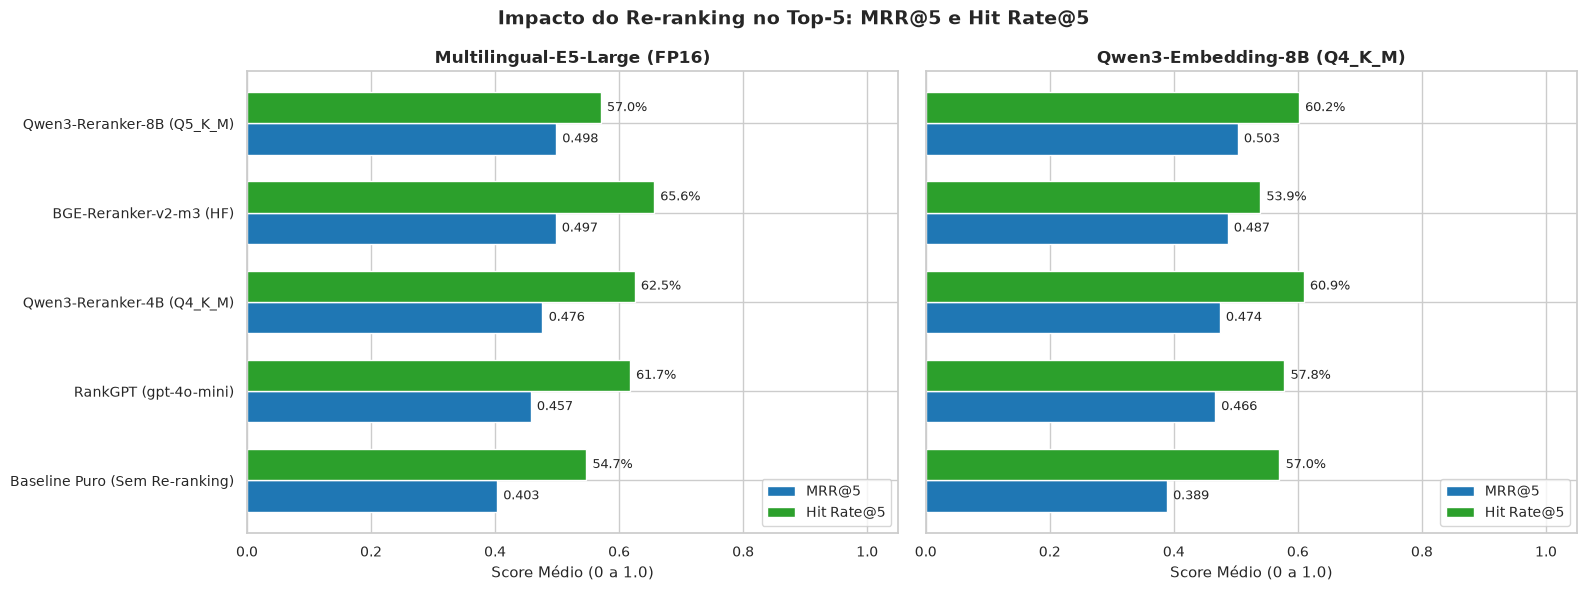

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for idx, base in enumerate(df["base_model"].unique()):
    ax = axes[idx]
    sub = df[df["base_model"] == base].sort_values(by="mrr@5_mean", ascending=True)
    
    y = np.arange(len(sub))
    h = 0.35
    
    bars1 = ax.barh(y - h/2, sub["mrr@5_mean"], h, label="MRR@5", color="#1f77b4")
    bars2 = ax.barh(y + h/2, sub["hit_rate@5_mean"], h, label="Hit Rate@5", color="#2ca02c")
    
    ax.set_yticks(y)
    ax.set_yticklabels(sub["reranker_name"], fontsize=10)
    ax.set_xlabel("Score Médio (0 a 1.0)")
    ax.set_title(BASE_LABELS.get(base, base), fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.legend(loc="lower right")
    
    for b in bars1:
        w = b.get_width()
        ax.text(w + 0.01, b.get_y() + b.get_height()/2, f"{w:.3f}", va="center", fontsize=9)
    for b in bars2:
        w = b.get_width()
        ax.text(w + 0.01, b.get_y() + b.get_height()/2, f"{w:.1%}", va="center", fontsize=9)

plt.suptitle("Impacto do Re-ranking no Top-5: MRR@5 e Hit Rate@5", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Ganhos Incrementais ($\Delta$ MRR@5) e Eficácia Relativa
O gráfico abaixo evidencia o salto qualitativo gerado pela reordenação em relação ao baseline puro de primeiro estágio ($K_{\text{cand}}=20 \rightarrow K=5$).


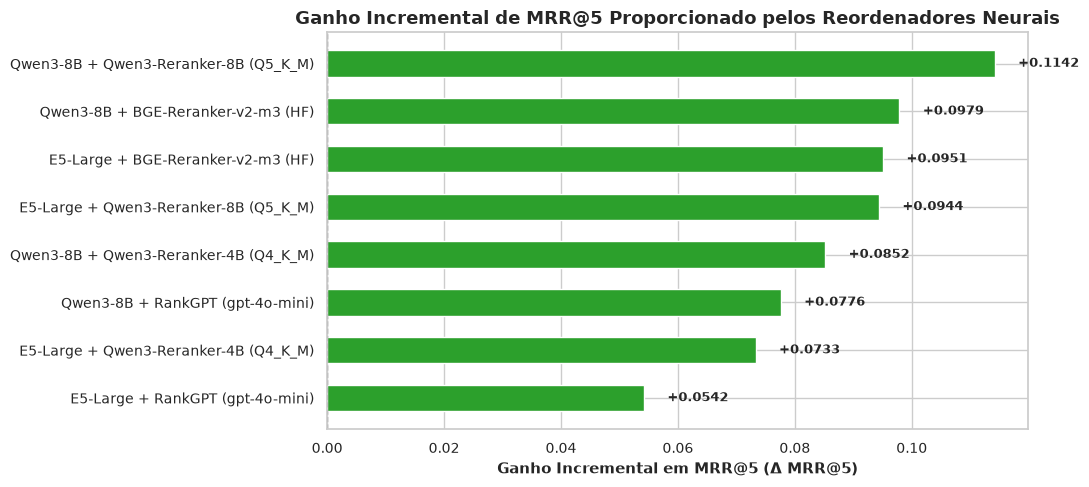

In [4]:
delta_df = df[df["reranker"] != "none"].copy()
delta_df["label"] = (
    delta_df["base_model"].map(lambda x: "Qwen3-8B" if "qwen" in x else "E5-Large")
    + " + "
    + delta_df["reranker_name"]
)
delta_df = delta_df.sort_values(by="delta_mrr@5", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in delta_df["delta_mrr@5"]]
y = np.arange(len(delta_df))

bars = ax.barh(y, delta_df["delta_mrr@5"], color=colors, height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(delta_df["label"], fontsize=10)
ax.set_xlabel("Ganho Incremental em MRR@5 (Δ MRR@5)", fontweight="bold")
ax.axvline(0, color="gray", linestyle="--", linewidth=1.0)
ax.set_title("Ganho Incremental de MRR@5 Proporcionado pelos Reordenadores Neurais", fontsize=13, fontweight="bold")

for b in bars:
    w = b.get_width()
    offset = 0.004 if w >= 0 else -0.015
    ax.text(w + offset, b.get_y() + b.get_height()/2, f"{w:+.4f}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Análise de Trade-off de Engenharia: Eficácia (MRR@5) vs. Custo Computacional (Latência)
Em sistemas industriais com requisitos de SLA e hardware restrito (como uma GPU de 8 GB), a latência adicional introduzida pelo re-ranking é um fator decisivo.


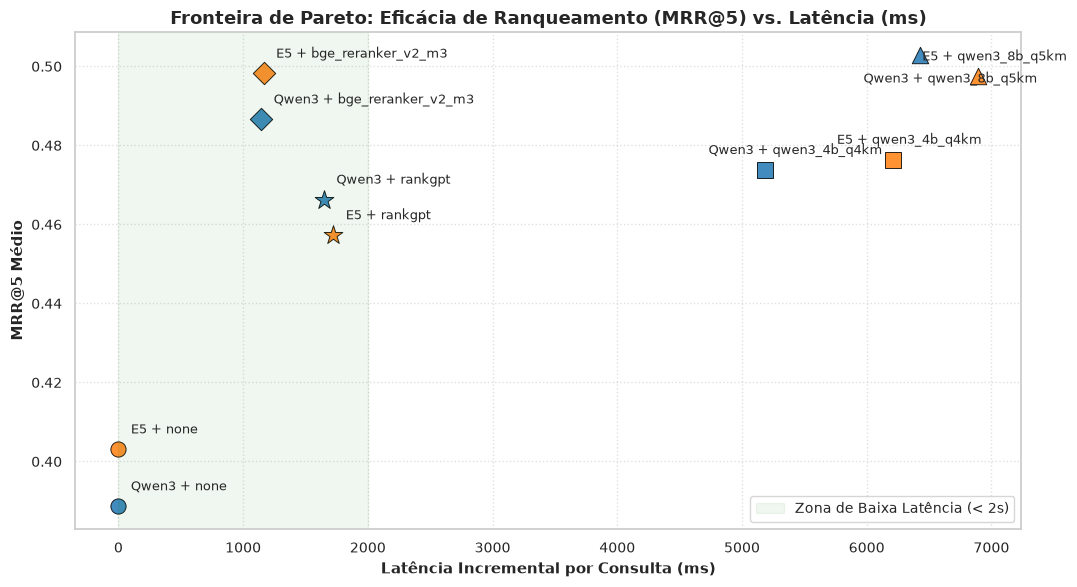

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

markers = {
    "none": ("o", 120),
    "qwen3_4b_q4km": ("s", 130),
    "qwen3_8b_q5km": ("^", 140),
    "bge_reranker_v2_m3": ("D", 130),
    "rankgpt": ("*", 200),
}
colors_base = {
    "qwen3_8b_q4km": "#1f77b4",
    "multilingual_e5_large": "#ff7f0e",
}

for _, row in df.iterrows():
    base = row["base_model"]
    rerank = row["reranker"]
    x = row["mean_latency_ms"]
    y = row["mrr@5_mean"]
    
    m, size = markers.get(rerank, ("o", 100))
    c = colors_base.get(base, "#333333")
    lbl = f"{'Qwen3' if 'qwen' in base else 'E5'} + {rerank}"
    
    ax.scatter(x, y, color=c, marker=m, s=size, alpha=0.85, edgecolors="black", linewidths=0.7)
    
    offset_x = 100 if x < 2000 else -450
    offset_y = 0.004 if y < 0.50 else -0.007
    ax.annotate(lbl, (x + offset_x, y + offset_y), fontsize=9)

ax.set_xlabel("Latência Incremental por Consulta (ms)", fontweight="bold")
ax.set_ylabel("MRR@5 Médio", fontweight="bold")
ax.set_title("Fronteira de Pareto: Eficácia de Ranqueamento (MRR@5) vs. Latência (ms)", fontsize=13, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)

# Destaque do Sweet Spot BGE-Reranker-v2-m3
ax.axvspan(0, 2000, color="green", alpha=0.06, label="Zona de Baixa Latência (< 2s)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


## 5. Perfil de Consumo de Recursos (VRAM, Hardware e Custo)

Na arquitetura serializada implementada, o descarregamento de VRAM entre o modelo de primeiro estágio e o reordenador garante operação contínua sem estouro de memória (*Out-Of-Memory*):

| Componente / Modelo | Tipo / Engine | Memória Alocada (VRAM) | Custo Operacional (USD / 1M consultas) | Dependência de Rede Externa |
| :--- | :---: | :---: | :---: | :---: |
| `Qwen3-Embedding-8B (Q4_K_M)` | Ollama (GGUF) | ~5.2 GB | $0.00 | Nenhuma (100% Offline) |
| `Multilingual-E5-Large (FP16)` | HuggingFace (PyTorch) | ~2.2 GB | $0.00 | Nenhuma (100% Offline) |
| `BGE-Reranker-v2-m3` | HuggingFace (PyTorch) | **~1.2 GB** | **$0.00** | **Nenhuma (100% Offline)** |
| `Qwen3-Reranker-4B (Q4_K_M)` | Ollama (GGUF) | **~2.5 GB** | **$0.00** | **Nenhuma (100% Offline)** |
| `Qwen3-Reranker-8B (Q5_K_M)` | Ollama (GGUF) | ~5.9 GB | $0.00 | Nenhuma (100% Offline) |
| `RankGPT (gpt-4o-mini)` | OpenAI Cloud API | 0.0 GB | ~$150.00 | Conexão de Internet Mandatória |


## 6. Conclusões Científicas e Recomendações para a Pesquisa / Projeto ICT

1. **Ganhos Substanciais com Re-ranking:**
   - A adição da etapa de re-ranking sobre o pool de 20 candidatos elevou o MRR@5 de **0.3887 $\rightarrow$ 0.5029 (+29.4%)** na base `qwen3_8b_q4km`, e de **0.4031 $\rightarrow$ 0.4866 (+20.7%)** na base `multilingual_e5_large`.
   - O Hit Rate@5 saltou de **54.7% $\rightarrow$ 62.5% (+7.8 p.p.)** com o `Qwen3-4B`, demonstrando que nós relevantes anteriormente na faixa 6–20 foram recuperados com sucesso para os Top-5.

2. **Superioridade dos Modelos Locais sobre o Baseline Comercial:**
   - Tanto o `BGE-Reranker-v2-m3` quanto os modelos `Qwen3-4B` e `Qwen3-8B` superaram a solução em nuvem `RankGPT (gpt-4o-mini)` em MRR@5.
   - Isso reflete o ajuste fino especializado para relevância de passagem (*passage ranking*) dos modelos dedicados em comparação com a abordagem genérica de ordenação listwise por prompt.

3. **Recomendação de Arquitetura de Produção para a CM Comandos:**
   - **Cenário de Alta Vazão / Baixa Latência:** `Multilingual-E5-Large` (ou ONNX INT8) no 1º estágio + `BGE-Reranker-v2-m3` no 2º estágio. Entrega ganho de MRR substancial com acréscimo de apenas **1.14 segundos** por consulta e menos de **1.5 GB de VRAM**.
   - **Cenário de Máxima Precisão:** `Qwen3-8B (Q4_K_M)` no 1º estágio + `Qwen3-8B (Q5_K_M)` ou `Qwen3-4B` no 2º estágio. Atinge o teto de **0.5029 de MRR@5** e **60.2% de Hit Rate@5**.
